# Introducción a la Ciencia de Datos: Tarea 2

Este notebook contiene el código de base para realizar la Tarea 2 del curso. Es la continuación de la Tarea 1, por lo que se utilizarán los mismos datos y se puede reutilizar cualquier parte del código de dicha tarea.

Puede copiar este notebook en su propio repositorio y trabajar sobre el mismo.
Las **instrucciones para ejecutar el notebook** están en la [página inicial del repositorio](https://gitlab.fing.edu.uy/maestria-cdaa/intro-cd).

Se utiliza el lenguaje Python y las librerías Pandas y scikit-learn. Para esta tarea se recomienda consultar la sección [Extracting features from text files](https://scikit-learn.org/stable/tutorial/text_analytics/working_with_text_data.html) de la documentación oficial de scikit-learn.

Recuerde que **se espera que no sea necesario revisar el código para corregir la tarea**, ya que todos los resultados y análisis relevantes deberían estar en el **informe en formato PDF**.

## Cargar bibliotecas (dependencias)
Recuerde instalar los requerimientos (`requirements.txt`) en el mismo entorno donde está ejecutando este notebook.

In [1]:
from time import time
from pathlib import Path

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

## Descarga del dataset
Se utilizan los mismos datos que en la Tarea 1. Ejecute la siguiente celda para descargar los datos y cargarlos en un dataframe de pandas.

In [2]:
ds = load_dataset("tomas-gr/all-the-news-2-1-Component-one-sampled", split="train", cache_dir="../data")
df = ds.to_pandas()

# Tres medios con mayor cantidad de artículos
# Cantidad de articulos por medio de prensa:
print("Cantidad de artículos por medio de prensa:")
print(df['publication'].value_counts())

# Tome los 3 medios con más artículos
top3 = df['publication'].dropna().value_counts().head(3).index
print('Los 3 medios con más artículos son:')
print(top3)

# Imprimir solo los articles completos de los 6 primeros articulos de The New York Times
print("Los 6 primeros artículos completos de The New York Times:")
nyt_articles = df[df['publication'] == 'The New York Times']['article'].head(6)

# Mostrar todo el texto sin truncar
pd.set_option('display.max_colwidth', None)

# Presentar cada artículo completo por separado para que no se corte
for i, article in enumerate(nyt_articles, start=1):
    print(f"\n--- Artículo {i} ---\n")
    print(article)


Cantidad de artículos por medio de prensa:
publication
Reuters               9431
The New York Times    2840
CNBC                  2623
The Hill              2349
People                1528
CNN                   1446
Refinery 29           1236
Vice                  1154
Mashable              1045
Business Insider       660
The Verge              594
TechCrunch             568
TMZ                    552
Vox                    549
Axios                  538
Politico               518
Washington Post        468
Buzzfeed News          376
Gizmodo                329
Economist              303
Wired                  231
Fox News               227
Vice News              187
New Republic           145
Hyperallergic          123
New Yorker              52
Name: count, dtype: int64
Los 3 medios con más artículos son:
Index(['Reuters', 'The New York Times', 'CNBC'], dtype='str', name='publication')
Los 6 primeros artículos completos de The New York Times:

--- Artículo 1 ---

Calculator Sure, if 

# Parte 1: Dataset y representación numérica de texto

## 1. Preparación del dataset
Se utilizará un conjunto de datos reducido de los **tres medios de prensa con mayor cantidad de artículos**.
Se espera que utilice su propia versión de la función `clean_text()` de la Tarea 1.

Particione los datos para generar un conjunto de test del 30% del total, utilizando muestreo estratificado.

**Sugerencia**: utilice el parámetro `stratify` de la función `train_test_split` de scikit-learn y fije también el valor de `random_state` para obtener resultados reproducibles.

In [3]:
def remover_plantillas(df):

    df = df.copy()

    mask = df['publication'].isin(['Reuters', 'CNBC'])

    df.loc[mask, 'article'] = df.loc[mask, 'article'].str.replace(
        r'^(.*?)(\((Reuters|CNBC)\)\s*-)',
        '',
        regex=True
    )

    return df

In [4]:
import re

def clean_text(series):

    text = series.fillna("").str.lower()

    # expandir contracciones
    contractions = {
        "i'm": "i am",
        "you're": "you are",
        "he's": "he is",
        "she's": "she is",
        "it's": "it is",
        "we're": "we are",
        "they're": "they are",
        "can't": "cannot",
        "won't": "will not",
        "don't": "do not",
        "doesn't": "does not"
    }

    for k, v in contractions.items():
        text = text.str.replace(k, v, regex=False)

    # reemplazar puntuación por espacios
    for punc in ["[", "\n", ",", ":", "?", "!", "(", ")", '"', "]", ";", ". "]:
        text = text.str.replace(punc, " ", regex=False)

    text = text.apply(lambda x: " ".join(
        w for w in x.split()
        if w.isalpha()   # SOLO letras puras
    ))

    # eliminar espacios múltiples
    text = text.str.replace(r"\s+", " ", regex=True).str.strip()

    return text

In [5]:
# TODO: Obtenga los tres medios con mayor cantidad de artículos y filtre el DataFrame
top_3_publications = df['publication'].dropna().value_counts().head(3).index
df_top_3 = df[df['publication'].isin(top_3_publications)]
print('Los 3 medios con más artículos son:')
print(top_3_publications)

# Remover plantillas
df_top_3 = remover_plantillas(df_top_3)
df_top_3["CleanText"] = clean_text(df_top_3["article"])


Los 3 medios con más artículos son:
Index(['Reuters', 'The New York Times', 'CNBC'], dtype='str', name='publication')


In [6]:
# TODO: Particione los datos en train y test (30% test), con muestreo estratificado
X = df_top_3["CleanText"]
y = df_top_3["publication"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)


## 2. Verificación del balance de clases
Genere una visualización que permita verificar que el balance de artículos de cada medio es similar en train y test.

Cantidad de artículos por publicación en los conjuntos de entrenamiento y prueba:

Set                 Test  Train
publication                    
CNBC                 787   1836
Reuters             2830   6601
The New York Times   852   1988


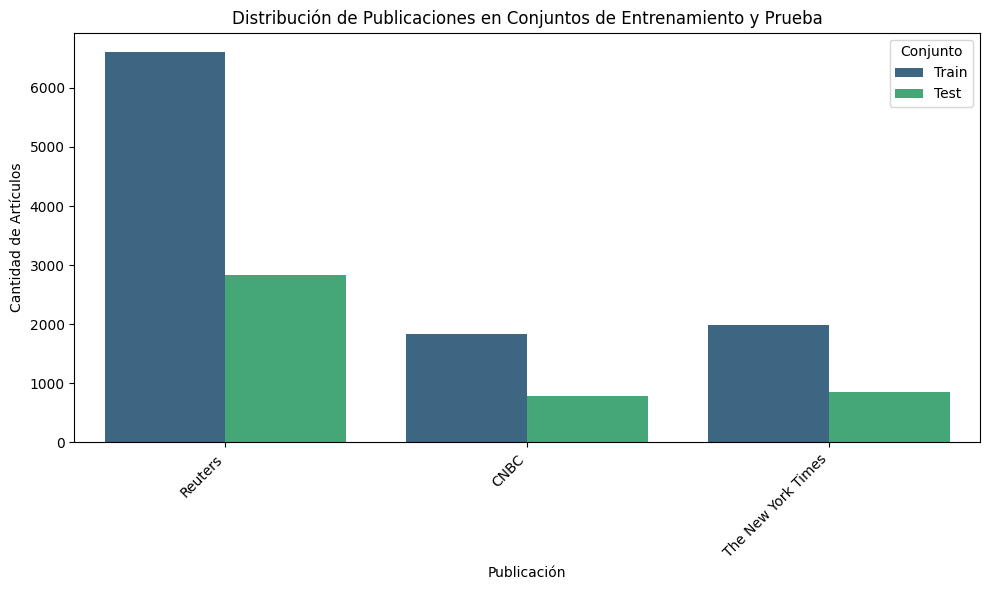

In [7]:
# Combine y_train and y_test for easier plotting
# First, convert them to DataFrames or Series to add a 'Set' column
y_train_df = y_train.to_frame(name='publication')
y_train_df['Set'] = 'Train'

y_test_df = y_test.to_frame(name='publication')
y_test_df['Set'] = 'Test'

combined_y_df = pd.concat([y_train_df, y_test_df])

# Calculate and print the counts per publication and set
counts_by_publication_and_set = combined_y_df.groupby(['publication', 'Set']).size().unstack(fill_value=0)
print("Cantidad de artículos por publicación en los conjuntos de entrenamiento y prueba:\n")
print(counts_by_publication_and_set)

# Create the count plot for visual verification
plt.figure(figsize=(10, 6))
sns.countplot(data=combined_y_df, x='publication', hue='Set', palette='viridis')
plt.title('Distribución de Publicaciones en Conjuntos de Entrenamiento y Prueba')
plt.xlabel('Publicación')
plt.ylabel('Cantidad de Artículos')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Conjunto')
plt.tight_layout()
plt.show()

## 3. Representación Bag of Words
Transforme el texto del conjunto de entrenamiento a una representación numérica (features) de conteo de palabras (*bag of words*).
Explique brevemente cómo funciona esta técnica y muestre un ejemplo.
En particular, explique el tamaño de la matriz resultante y la razón por la que es una matriz *sparse*.

**Sugerencia**: puede ser útil imaginar qué sucedería con la memoria RAM requerida si no estuviéramos trabajando con un conjunto de datos reducido.

In [8]:
# Inicializar CountVectorizer
vectorizer = CountVectorizer()

# Handle potential NaN values by filling them with an empty string
X_train_processed = X_train.fillna('')

# Fit and transform X_train_processed
X_train_bow = vectorizer.fit_transform(X_train_processed)

# Show the size of the resulting matrix
print(f"Shape of the Bag of Words matrix: {X_train_bow.shape}")

# Show an example: the first words of the vocabulary and their counts in a document
# Let's take the first document from X_train for example
first_document_index = 0
first_document_bow = X_train_bow[first_document_index].toarray()

# Get feature names (vocabulary)
vocabulary = vectorizer.get_feature_names_out()

# Get words and their counts for the first document
document_word_counts = {}
for word_index in first_document_bow.nonzero()[1]:
    word = vocabulary[word_index]
    count = first_document_bow[0, word_index]
    document_word_counts[word] = count

print(f"\nExample from document {first_document_index}:")
print(f"Original text: {X_train_processed.iloc[first_document_index][:1000]}...") # Show first 200 chars
print(f"Word counts (first 20 words): {dict(list(document_word_counts.items())[:20])}")

Shape of the Bag of Words matrix: (10425, 78284)

Example from document 0:
Original text: the two biggest container shipping companies on tuesday said they have been cleared in an investigation of the sector by the department of justice doj maersk and mediterranean shipping company msc were among several companies ordered to testify in an antitrust investigation that began in over practices by an industry that is the backbone of world trade other lines included hapag lloyd container companies which transport everything from tvs to bananas have tried reduce costs through alliances to pool sailing schedules and port calls critics say this can lead to reduced services and increased prices for customers msc which is the line said it had been informed by the doj that the department had closed its investigation into msc and the global container shipping industry without bringing charges or imposing penalties is an important decision where the global container shipping industry has once again

## 4. Representación TF-IDF
Explique brevemente qué es un **n-grama**.
Obtenga la representación numérica *Term Frequency - Inverse Document Frequency* (TF-IDF).
Explique brevemente en qué consiste esta transformación adicional.

In [9]:
X_train_processed = clean_text(X_train)

tfidf_vectorizer = TfidfVectorizer(
    use_idf=True,
    stop_words='english',
    ngram_range=(1,1)
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_processed)

# Show the size of the resulting matrix
print(f"Shape of the TF-IDF matrix: {X_train_tfidf.shape}")

print(tfidf_vectorizer.get_feature_names_out()[:20])

Shape of the TF-IDF matrix: (10425, 77980)
['aa' 'aaa' 'aaalto' 'aab' 'aabar' 'aac' 'aachen' 'aadmi' 'aadvantage'
 'aadya' 'aah' 'aaii' 'aakash' 'aaker' 'aal' 'aalborg' 'aam' 'aamc'
 'aamin' 'aap']


In [ ]:
first_document_index = 0

# Obtener el texto original del primer documento
original_text_first_doc = X_train_processed.iloc[first_document_index]

# Obtener los nombres de las características (vocabulario) del vectorizador TF-IDF
vocabulary = tfidf_vectorizer.get_feature_names_out()

# Obtener los índices y puntajes de los valores TF-IDF no nulos para el primer documento
non_zero_indices = X_train_tfidf[first_document_index].nonzero()[1]
non_zero_scores = X_train_tfidf[first_document_index, non_zero_indices].toarray().flatten()

# Crear una lista de tuplas (palabra, puntaje) para el primer documento
word_score_pairs = []
for i, idx in enumerate(non_zero_indices):
    word = vocabulary[idx]
    score = non_zero_scores[i]
    word_score_pairs.append((word, score))

# Ordenar la lista de tuplas por puntaje TF-IDF en orden descendente
word_score_pairs.sort(key=lambda x: x[1], reverse=True)

print(f"\nMayores 20 valores TF-IDF para el documento {first_document_index}:")
# Mostrar las 20 palabras con mayor puntaje TF-IDF y sus puntajes
for i, (word, score) in enumerate(word_score_pairs):
    if i >= 20:
        break
    print(f"  {word}: {score:.4f}")


Top 20 TF-IDF values for document 0:
  container: 0.4121
  maersk: 0.3812
  hapag: 0.2714
  investigation: 0.2622
  msc: 0.2402
  doj: 0.2107
  shipping: 0.2082
  lloyd: 0.1902
  moller: 0.1810
  fines: 0.1166
  antitrust: 0.1139
  industry: 0.0968
  practices: 0.0943
  holtse: 0.0905
  companies: 0.0849
  global: 0.0834
  tuesday: 0.0784
  bananas: 0.0774
  eckert: 0.0774
  closed: 0.0772


## 5. Visualización PCA sobre TF-IDF
Muestre en un mapa el conjunto de entrenamiento, utilizando las dos primeras componentes PCA sobre los vectores de TF-IDF.
Analice los resultados y compare qué sucede si utiliza:
- a) el filtrado de `stop_words` para idioma inglés;
- b) el parámetro `use_idf=True`;
- c) `ngram_range=(1,2)`.

Opcionalmente, también puede analizar qué sucede si no elimina los signos de puntuación.

¿Se pueden separar los medios de prensa utilizando sólo 2 componentes principales?
Haga una visualización que permita entender cómo varía la varianza explicada a medida que se agregan componentes (por ejemplo, hasta 10 componentes).

Discuta además si la separación observada puede deberse a diferencias de estilo editorial, a diferencias temáticas o a pistas explícitas del medio que no hayan sido removidas en la limpieza.

In [ ]:
# TODO: Compare los resultados de PCA con distintas configuraciones del TfidfVectorizer:


In [ ]:
# TODO: Genere una visualización que muestre cómo varía la varianza explicada
# a medida que se agregan componentes PCA (por ejemplo, hasta 10 componentes).



In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

def plot_tfidf_pca(
    X,
    y,
    use_idf=False,
    stop_words=None,
    ngram_range=(1, 1),
    n_components=2,
    random_state=42,
    figsize=(10, 8)
):
    """
    Aplica TF-IDF y PCA sobre un conjunto de textos y grafica los resultados.
    """

    # Limpiar NaNs
    X_processed = X.fillna('')

    # TF-IDF
    vectorizer = TfidfVectorizer(
        use_idf=use_idf,
        stop_words=stop_words,
        ngram_range=ngram_range,
    )

    X_tfidf = vectorizer.fit_transform(X_processed)

    # PCA
    pca = PCA(
        n_components=n_components,
        random_state=random_state
    )

    X_pca = pca.fit_transform(X_tfidf.toarray())

    # DataFrame para plot
    pca_df = pd.DataFrame(
        X_pca,
        columns=[f'PC{i+1}' for i in range(n_components)]
    )

    pca_df['label'] = y.reset_index(drop=True)

    # Plot (solo si hay 2 componentes)
    if n_components == 2:
        plt.figure(figsize=figsize)

        sns.scatterplot(
            data=pca_df,
            x='PC1',
            y='PC2',
            hue='label',
            alpha=0.7
        )

        plt.title('PCA sobre TF-IDF')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return {
        "vectorizer": vectorizer,
        "X_tfidf": X_tfidf,
        "pca": pca,
        "X_pca": X_pca,
        "explained_variance": pca.explained_variance_ratio_
    }

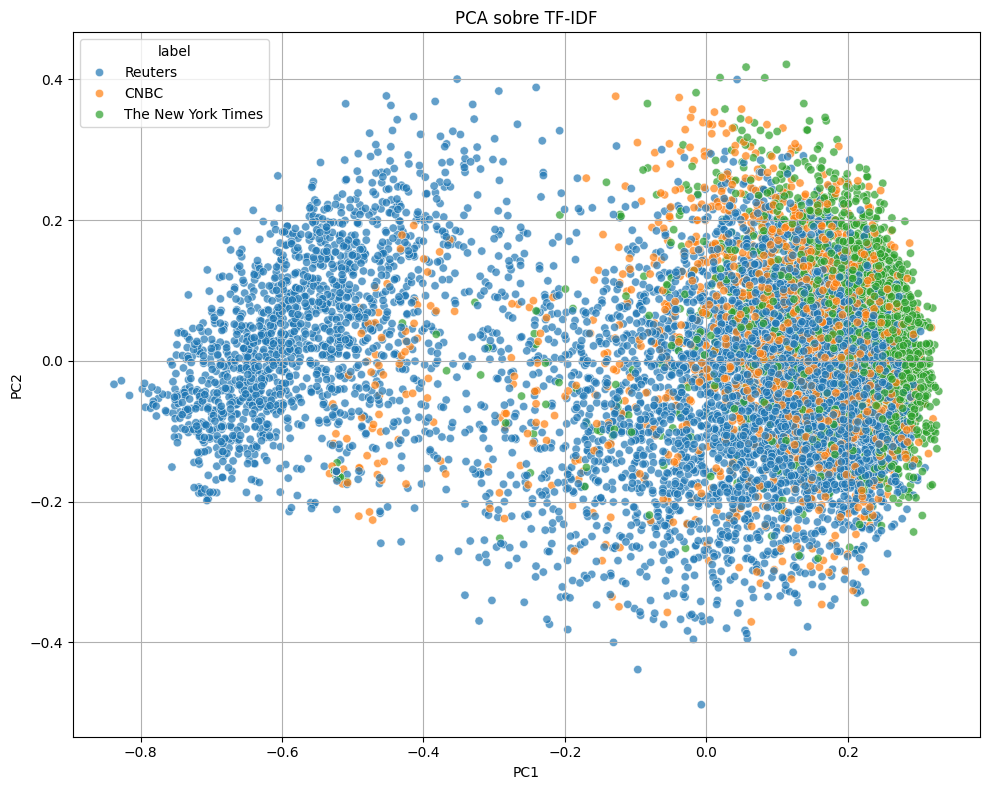

In [18]:
result = plot_tfidf_pca(
    X_train,
    y_train,
    use_idf=False,
    stop_words=None,
    ngram_range=(1,1)
)

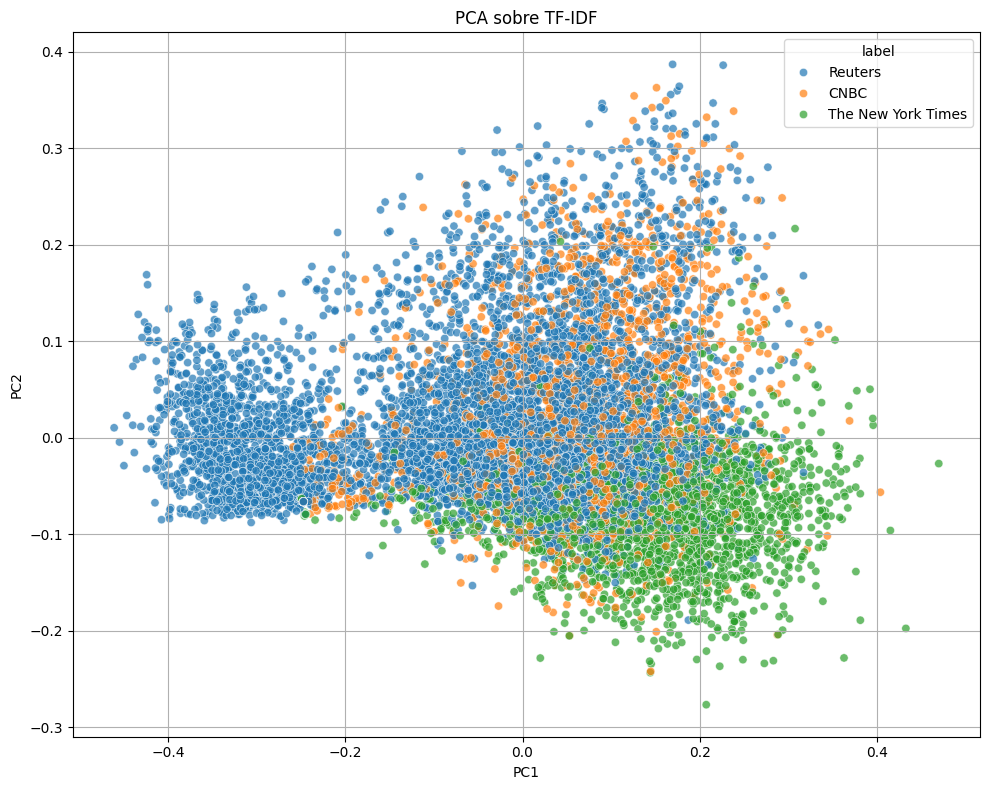

In [19]:
result = plot_tfidf_pca(
    X_train,
    y_train,
    use_idf=True,
    stop_words=None,
    ngram_range=(1,1)
)

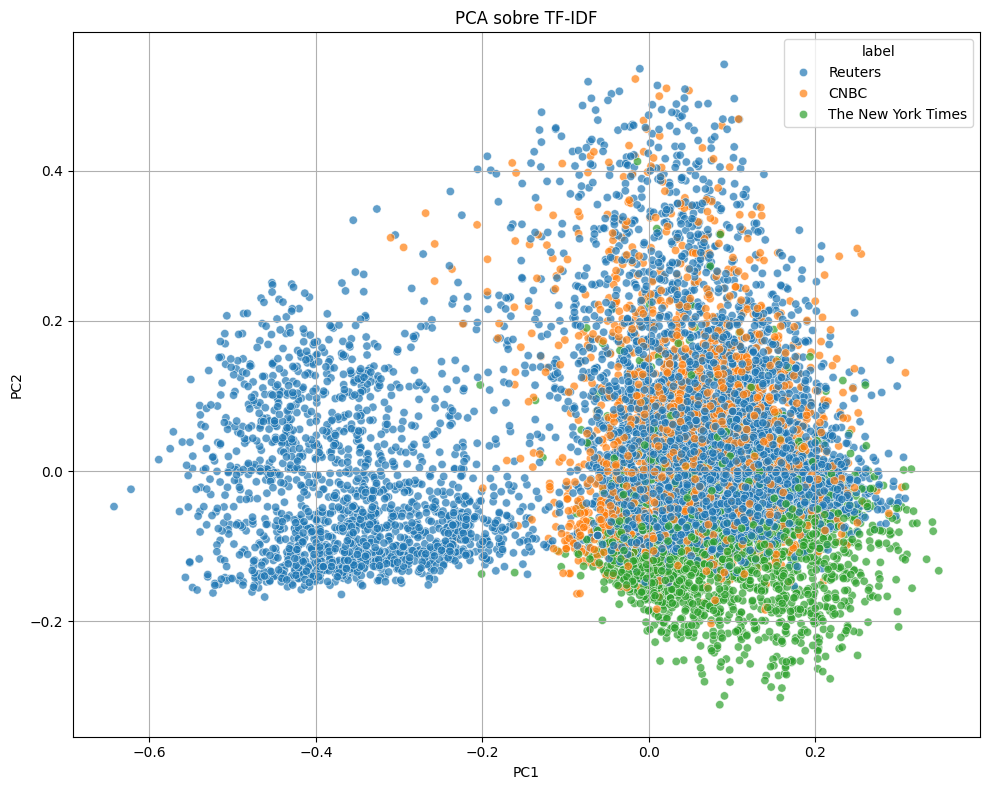

In [20]:
result = plot_tfidf_pca(
    X_train,
    y_train,
    use_idf=False,
    stop_words='english',
    ngram_range=(1,1)
)

In [15]:
result = plot_tfidf_pca(
    X_train,
    y_train,
    use_idf=False,
    stop_words=None,
    ngram_range=(1,2)
)

MemoryError: Unable to allocate 114. GiB for an array with shape (10425, 1465353) and data type float64

# Parte 2: Entrenamiento y Evaluación de Modelos

## 1. Multinomial Naive Bayes
Entrene el modelo *Multinomial Naive Bayes* para clasificar los artículos según a qué medio de prensa pertenece el texto.
Utilice dicho modelo para clasificar los artículos del conjunto de test, y reporte el valor de *accuracy* y la **matriz de confusión**.
Reporte además el valor de *precision* y *recall* para cada medio.
Explique cómo se relacionan estos valores con la matriz anterior.

¿Qué problemas puede tener el hecho de mirar solamente el valor de *accuracy*?
Considere qué sucedería con esta métrica si el desbalance de datos fuera aún mayor entre medios.

**Sugerencia**: utilice el método `from_predictions` de `ConfusionMatrixDisplay` para realizar la matriz.

Accuracy: 0.7216


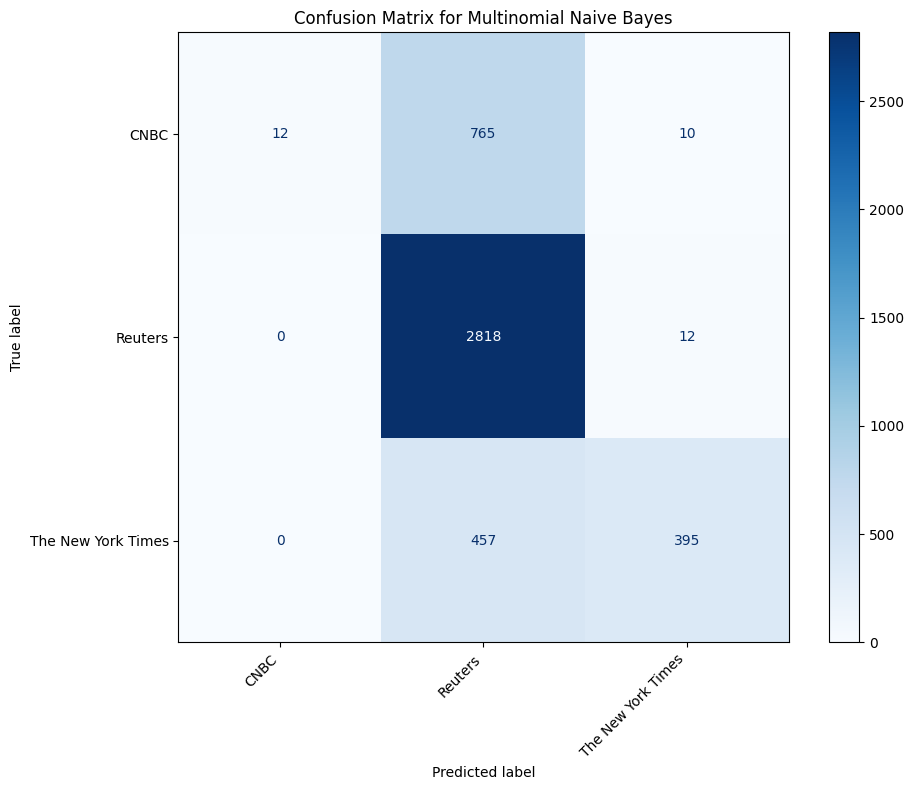


Classification Report:
                    precision    recall  f1-score   support

              CNBC       1.00      0.02      0.03       787
           Reuters       0.70      1.00      0.82      2830
The New York Times       0.95      0.46      0.62       852

          accuracy                           0.72      4469
         macro avg       0.88      0.49      0.49      4469
      weighted avg       0.80      0.72      0.64      4469



In [21]:
# TODO: Entrene Multinomial Naive Bayes sobre X_train_tfidf

mnb = MultinomialNB()
mnb.fit(X_train_tfidf, y_train)

# Handle potential NaN values in X_test by filling them with an empty string
X_test_processed = X_test.fillna('')

# Transform X_test using the fitted tfidf_vectorizer
X_test_tfidf = tfidf_vectorizer.transform(X_test_processed)

# Make predictions on the test set
y_pred = mnb.predict(X_test_tfidf)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Display Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap=plt.cm.Blues, ax=ax)
ax.set_title('Confusion Matrix for Multinomial Naive Bayes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Display Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

## 2. Validación cruzada y búsqueda de hiperparámetros
Explique cómo funciona la técnica de **validación cruzada** (*cross-validation*).
Implemente una búsqueda de hiperparámetros usando `GridSearchCV`.
Genere una visualización que permita comparar las métricas (por ejemplo, *accuracy*) de los distintos modelos entrenados, viendo el valor promedio y la variabilidad de las mismas en todos los *splits* (por ejemplo, en un gráfico de violín).

In [ ]:
param_grid = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]  # Smoothing parameter
}

# Initialize Multinomial Naive Bayes model
mnb = MultinomialNB()

# Initialize GridSearchCV
grid_search = GridSearchCV(
    mnb,
    param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',  # Metric to optimize
    n_jobs=-1,  # Use all available CPU cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train_tfidf, y_train)

print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract results from GridSearchCV
results = grid_search.cv_results_

# Prepare data for plotting
alpha_values = results['param_alpha']
mean_test_scores = results['mean_test_score']
std_test_scores = results['std_test_score']

# Create a DataFrame to hold the scores for each split for easier plotting
plot_data = []
for i, alpha in enumerate(alpha_values):
    for split_idx in range(grid_search.cv):
        split_score_key = f'split{split_idx}_test_score'
        if split_score_key in results:
            plot_data.append({
                'alpha': alpha,
                'accuracy': results[split_score_key][i],
                'split': split_idx
            })

scores_df = pd.DataFrame(plot_data)

# Convert 'alpha' to string type to treat it as categorical for plotting
scores_df['alpha'] = scores_df['alpha'].astype(str)

plt.figure(figsize=(10, 6))
sns.violinplot(x='alpha', y='accuracy', data=scores_df, hue='alpha', palette='viridis', legend=False) # Fixed FutureWarning

# Calculate the mean accuracy for each alpha
mean_accuracies = scores_df.groupby('alpha')['accuracy'].mean().reset_index()

# Convert 'alpha' to string type for mean_accuracies as well
mean_accuracies['alpha'] = mean_accuracies['alpha'].astype(str)

# Add scatter plot for the mean accuracy
sns.scatterplot(
    x='alpha',
    y='accuracy',
    data=mean_accuracies,
    color='red', # Choose a distinct color for the mean points
    marker='X', # Choose a distinct marker for the mean points
    s=15, # Size of the markers (reduced from 150 to 50)
    zorder=5, # Ensure the markers are on top of the violins
    label='Mean Accuracy'
)

plt.title('Accuracy Distribution for Different Alpha Values Across CV Splits with Mean')
plt.xlabel('Alpha (Smoothing Parameter)')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

## 3. Entrenamiento final con el mejor modelo
Elija el mejor modelo (mejores parámetros) y vuelva a entrenar sobre todo el conjunto de entrenamiento disponible (sin quitar datos para validación).
Reporte el valor final de las métricas y la matriz de confusión.
Discuta las limitaciones de utilizar un modelo basado en *bag of words* o TF-IDF para el análisis de texto.

In [ ]:
# Get the best alpha parameter from GridSearchCV
best_alpha = grid_search.best_params_['alpha']

# Initialize the final Multinomial Naive Bayes model with the best alpha
final_mnb_model = MultinomialNB(alpha=best_alpha)

# Train the final model on the entire training set (X_train_tfidf, y_train)
final_mnb_model.fit(X_train_tfidf, y_train)

print(f"Final Multinomial Naive Bayes model trained with alpha={best_alpha}")

In [ ]:
# Make predictions on the test set using the final model
y_pred_final = final_mnb_model.predict(X_test_tfidf)

# Calculate accuracy
accuracy_final = accuracy_score(y_test, y_pred_final)
print(f"Final Model Accuracy on Test Set: {accuracy_final:.4f}")

# Display Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final, cmap=plt.cm.Blues, ax=ax)
ax.set_title('Confusion Matrix for Final Multinomial Naive Bayes Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Display Classification Report
print("\nClassification Report for Final Model:")
print(classification_report(y_test, y_pred_final))

## 4. Modelo alternativo
Evalúe al menos un modelo más (dentro de scikit-learn) aparte de *Multinomial Naive Bayes* para clasificar el texto utilizando las mismas *features* de texto.
Explique brevemente cómo funciona y compare los resultados con el anterior.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model
# 'liblinear' solver works well for small datasets and L1/L2 regularization
# 'ovr' (one-vs-rest) is suitable for multiclass classification
# max_iter is increased to ensure convergence
lr_model = LogisticRegression(solver='liblinear', multi_class='ovr', max_iter=1000, random_state=42)

# Train the Logistic Regression model
lr_model.fit(X_train_tfidf, y_train)

# Make predictions on the test set using the Logistic Regression model
y_pred_lr = lr_model.predict(X_test_tfidf)

# Calculate accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Model Accuracy on Test Set: {accuracy_lr:.4f}")

# Display Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, cmap=plt.cm.Greens, ax=ax)
ax.set_title('Confusion Matrix for Logistic Regression Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Display Classification Report
print("\nClassification Report for Logistic Regression Model:")
print(classification_report(y_test, y_pred_lr))

## 5. Cambio de medio de prensa
Evalúe el problema cambiando al menos un medio de prensa.
En particular, observe el (des)balance de datos y los problemas que pueda generar, así como cualquier indicio que pueda ver en el mapeo previo con PCA.
Puede ser útil comentar acerca de técnicas como sobre-muestreo y submuestreo; no es necesario implementarlas.

## Re-evaluation with Reuters, The New York Times, and The Hill

In [ ]:
# --- Nueva selección de medios ---
# Re-evaluación del modelo con Reuters, The New York Times y The Hill.

print("--------------------------------------------------------------------------------")
print("Re-evaluating with new publications: Reuters, The New York Times, and The Hill")
print("--------------------------------------------------------------------------------")

# New set of publications: Reuters, The New York Times, and The Hill
new_publications_hill_1 = ['Reuters', 'The New York Times', 'The Hill']

# Filter the original DataFrame 'df' for these new publications
df_new_selection_hill_1 = df[df['publication'].isin(new_publications_hill_1)].copy()

# Check if 'The Hill' is actually present in the original dataset and selected
if not 'The Hill' in df_new_selection_hill_1['publication'].unique():
    print("Warning: 'The Hill' not found in the dataset. Please check publication names.")
    print(f"Available publications in filtered dataset: {df_new_selection_hill_1['publication'].unique()}")
else:
    print(f"Selected publications: {df_new_selection_hill_1['publication'].unique()}")

# Aplique clean_text sobre la columna de texto elegida y cree una nueva columna "CleanText"
df_new_selection_hill_1["CleanText"] = clean_text(df_new_selection_hill_1, "article")

# Drop rows where 'CleanText' might be empty or NaN after cleaning
df_new_selection_hill_1.dropna(subset=["CleanText"], inplace=True)

print(f"\nNumber of articles in the new selection: {len(df_new_selection_hill_1)}")

# --- Análisis del balance de clases en este nuevo conjunto de datos ---
X_new_hill_1 = df_new_selection_hill_1["CleanText"]
y_new_hill_1 = df_new_selection_hill_1["publication"]

# Print balance before splitting
print("\nBalance de clases en el nuevo conjunto de datos (antes de split):")
print(y_new_hill_1.value_counts())

# Particione los datos en train y test (30% test), con muestreo estratificado
X_train_new_hill_1, X_test_new_hill_1, y_train_new_hill_1, y_test_new_hill_1 = train_test_split(
    X_new_hill_1, y_new_hill_1, test_size=0.3, stratify=y_new_hill_1, random_state=42
)

# Combine y_train_new_hill_1 and y_test_new_hill_1 for easier plotting
y_train_df_new_hill_1 = y_train_new_hill_1.to_frame(name='publication')
y_train_df_new_hill_1['Set'] = 'Train'

y_test_df_new_hill_1 = y_test_new_hill_1.to_frame(name='publication')
y_test_df_new_hill_1['Set'] = 'Test'

combined_y_df_new_hill_1 = pd.concat([y_train_df_new_hill_1, y_test_df_new_hill_1])

# Calculate and print the counts per publication and set
counts_by_publication_and_set_new_hill_1 = combined_y_df_new_hill_1.groupby(['publication', 'Set']).size().unstack(fill_value=0)
print("\nCantidad de artículos por publicación en los nuevos conjuntos de entrenamiento y prueba:\n")
print(counts_by_publication_and_set_new_hill_1)

# Create the count plot for visual verification
plt.figure(figsize=(10, 6))
sns.countplot(data=combined_y_df_new_hill_1, x='publication', hue='Set', palette='viridis')
plt.title('Distribución de Nuevas Publicaciones en Conjuntos de Entrenamiento y Prueba (The Hill)')
plt.xlabel('Publicación')
plt.ylabel('Cantidad de Artículos')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Conjunto')
plt.tight_layout()
plt.show()

# --- TF-IDF Vectorization for new dataset ---
# Re-initialize TfidfVectorizer for the new dataset
tfidf_vectorizer_new_hill_1 = TfidfVectorizer(use_idf=True, stop_words='english')

# Handle potential NaN values by filling them with an empty string
X_train_processed_new_hill_1 = X_train_new_hill_1.fillna('')
X_test_processed_new_hill_1 = X_test_new_hill_1.fillna('')

# Fit and transform X_train_new_hill_1, then transform X_test_new_hill_1
X_train_tfidf_new_hill_1 = tfidf_vectorizer_new_hill_1.fit_transform(X_train_processed_new_hill_1)
X_test_tfidf_new_hill_1 = tfidf_vectorizer_new_hill_1.transform(X_test_processed_new_hill_1)

print(f"\nShape of the new TF-IDF matrix (Train): {X_train_tfidf_new_hill_1.shape}")
print(f"Shape of the new TF-IDF matrix (Test): {X_test_tfidf_new_hill_1.shape}")

# --- Entrenamiento y evaluación del modelo Multinomial Naive Bayes con el nuevo conjunto ---
# Initialize Multinomial Naive Bayes model with the best alpha found previously (0.1)
mnb_new_hill_1 = MultinomialNB(alpha=0.1)

# Train the model on the new training set
mnb_new_hill_1.fit(X_train_tfidf_new_hill_1, y_train_new_hill_1)

# Make predictions on the new test set
y_pred_new_hill_1 = mnb_new_hill_1.predict(X_test_tfidf_new_hill_1)

# Calculate accuracy
accuracy_new_hill_1 = accuracy_score(y_test_new_hill_1, y_pred_new_hill_1)
print(f"\nAccuracy of Multinomial Naive Bayes with new publications (The Hill) on Test Set: {accuracy_new_hill_1:.4f}")

# Display Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test_new_hill_1, y_pred_new_hill_1, cmap=plt.cm.Blues, ax=ax)
ax.set_title('Confusion Matrix for Multinomial Naive Bayes (The Hill)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Display Classification Report
print("\nClassification Report for Multinomial Naive Bayes (The Hill):")
print(classification_report(y_test_new_hill_1, y_pred_new_hill_1))


## Re-evaluation with The Hill, The New York Times, and CNBC

In [ ]:
# --- Nueva selección de medios ---
# Re-evaluación del modelo con The Hill, The New York Times y CNBC.

print("--------------------------------------------------------------------------------")
print("Re-evaluating with new publications: The Hill, The New York Times, and CNBC")
print("--------------------------------------------------------------------------------")

# New set of publications: The Hill, The New York Times, and CNBC
new_publications_hill_cnbc = ['The Hill', 'The New York Times', 'CNBC']

# Filter the original DataFrame 'df' for these new publications
df_new_selection_hill_cnbc = df[df['publication'].isin(new_publications_hill_cnbc)].copy()

# Check if 'The Hill' is actually present in the original dataset and selected
if not 'The Hill' in df_new_selection_hill_cnbc['publication'].unique():
    print("Warning: 'The Hill' not found in the dataset. Please check publication names.")
    print(f"Available publications in filtered dataset: {df_new_selection_hill_cnbc['publication'].unique()}")
else:
    print(f"Selected publications: {df_new_selection_hill_cnbc['publication'].unique()}")

# Aplique clean_text sobre la columna de texto elegida y cree una nueva columna "CleanText"
df_new_selection_hill_cnbc["CleanText"] = clean_text(df_new_selection_hill_cnbc, "article")

# Drop rows where 'CleanText' might be empty or NaN after cleaning
df_new_selection_hill_cnbc.dropna(subset=["CleanText"], inplace=True)

print(f"\nNumber of articles in the new selection: {len(df_new_selection_hill_cnbc)}")

# --- Análisis del balance de clases en este nuevo conjunto de datos ---
X_new_hill_cnbc = df_new_selection_hill_cnbc["CleanText"]
y_new_hill_cnbc = df_new_selection_hill_cnbc["publication"]

# Print balance before splitting
print("\nBalance de clases en el nuevo conjunto de datos (antes de split):")
print(y_new_hill_cnbc.value_counts())

# Particione los datos en train y test (30% test), con muestreo estratificado
X_train_new_hill_cnbc, X_test_new_hill_cnbc, y_train_new_hill_cnbc, y_test_new_hill_cnbc = train_test_split(
    X_new_hill_cnbc, y_new_hill_cnbc, test_size=0.3, stratify=y_new_hill_cnbc, random_state=42
)

# Combine y_train_new_hill_cnbc and y_test_new_hill_cnbc for easier plotting
y_train_df_new_hill_cnbc = y_train_new_hill_cnbc.to_frame(name='publication')
y_train_df_new_hill_cnbc['Set'] = 'Train'

y_test_df_new_hill_cnbc = y_test_new_hill_cnbc.to_frame(name='publication')
y_test_df_new_hill_cnbc['Set'] = 'Test'

combined_y_df_new_hill_cnbc = pd.concat([y_train_df_new_hill_cnbc, y_test_df_new_hill_cnbc])

# Calculate and print the counts per publication and set
counts_by_publication_and_set_new_hill_cnbc = combined_y_df_new_hill_cnbc.groupby(['publication', 'Set']).size().unstack(fill_value=0)
print("\nCantidad de artículos por publicación en los nuevos conjuntos de entrenamiento y prueba:\n")
print(counts_by_publication_and_set_new_hill_cnbc)

# Create the count plot for visual verification
plt.figure(figsize=(10, 6))
sns.countplot(data=combined_y_df_new_hill_cnbc, x='publication', hue='Set', palette='viridis')
plt.title('Distribución de Nuevas Publicaciones en Conjuntos de Entrenamiento y Prueba (The Hill, CNBC)')
plt.xlabel('Publicación')
plt.ylabel('Cantidad de Artículos')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Conjunto')
plt.tight_layout()
plt.show()

# --- TF-IDF Vectorization for new dataset ---
# Re-initialize TfidfVectorizer for the new dataset
tfidf_vectorizer_new_hill_cnbc = TfidfVectorizer(use_idf=True, stop_words='english')

# Handle potential NaN values by filling them with an empty string
X_train_processed_new_hill_cnbc = X_train_new_hill_cnbc.fillna('')
X_test_processed_new_hill_cnbc = X_test_new_hill_cnbc.fillna('')

# Fit and transform X_train_new_hill_cnbc, then transform X_test_new_hill_cnbc
X_train_tfidf_new_hill_cnbc = tfidf_vectorizer_new_hill_cnbc.fit_transform(X_train_processed_new_hill_cnbc)
X_test_tfidf_new_hill_cnbc = tfidf_vectorizer_new_hill_cnbc.transform(X_test_processed_new_hill_cnbc)

print(f"\nShape of the new TF-IDF matrix (Train): {X_train_tfidf_new_hill_cnbc.shape}")
print(f"Shape of the new TF-IDF matrix (Test): {X_test_tfidf_new_hill_cnbc.shape}")

# --- Entrenamiento y evaluación del modelo Multinomial Naive Bayes con el nuevo conjunto ---
# Initialize Multinomial Naive Bayes model with the best alpha found previously (0.1)
mnb_new_hill_cnbc = MultinomialNB(alpha=0.1)

# Train the model on the new training set
mnb_new_hill_cnbc.fit(X_train_tfidf_new_hill_cnbc, y_train_new_hill_cnbc)

# Make predictions on the new test set
y_pred_new_hill_cnbc = mnb_new_hill_cnbc.predict(X_test_tfidf_new_hill_cnbc)

# Calculate accuracy
accuracy_new_hill_cnbc = accuracy_score(y_test_new_hill_cnbc, y_pred_new_hill_cnbc)
print(f"\nAccuracy of Multinomial Naive Bayes with new publications (The Hill, CNBC) on Test Set: {accuracy_new_hill_cnbc:.4f}")

# Display Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test_new_hill_cnbc, y_pred_new_hill_cnbc, cmap=plt.cm.Blues, ax=ax)
ax.set_title('Confusion Matrix for Multinomial Naive Bayes (The Hill, CNBC)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Display Classification Report
print("\nClassification Report for Multinomial Naive Bayes (The Hill, CNBC):")
print(classification_report(y_test_new_hill_cnbc, y_pred_new_hill_cnbc))


## 6. Técnica alternativa de extracción de features
Busque información sobre al menos una técnica alternativa de extraer *features* de texto.
Explique brevemente cómo funciona y qué tipo de diferencias esperaría en los resultados.
No se espera que implemente nada en esta parte.

*TODO: Escriba su análisis en el informe.*

## 7. Opcional: Clasificación a nivel de título
Repita la clasificación con los tres medios de prensa originales, pero esta vez clasificando a nivel de **título** en lugar de artículo completo.

In [ ]:
# Opcional: Repita el pipeline de clasificación utilizando el título del artículo
# en lugar del cuerpo del texto.


Cosas a probar:



1.   Eliminar la palabra reuters
2.   Descartar los articulos sin cuerpo o muy cortos
3.   Opcional entrenar sobre componentes PCA

